# Profitable App Profile in Multi-Platform Markets

## Introduction

The goal for this project is to investigate and find an app profile that can be profitable in both the App Store and Google Play markets. As analysts for a company which builds Android and iOS, we must enable our team to make data-backed decisions behind the apps they build.

Our comapany only builds apps which are free to download and install. Therefore, our main source of revenue consists of in-app ads. This is importabt because the number of users of our apps determines our revenue for any given app. In other words, the more users who see and engage with the ads, the better. Our goal for this project is to analyze data to help our developers understand what type of apps are likely to attract more users.

## Loading the Data and Initial Investigation

### Data Sources
- `android_apps` is a dataset of approximatey 10,000 Android apps from Google Play; data was collected in August 2018; sources from here: [link](https://www.kaggle.com/datasets/lava18/google-play-store-apps).
- `apple_apps` is a dataset of approximately 7,000 iOS apps from the Apple App Store; the data was collected in July 2017; sourced from here: [link](https://www.kaggle.com/datasets/ramamet4/app-store-apple-data-set-10k-apps).

### Initial Investigation Analysis
- Load the data with reader package
- Seperate the `headers`, or the column names, from the rest of the data which seperates the beginning string with the other data types; allows us to infer what variables we can look at for insight
- Defined the `explore_data()` function with the parameters of the dataset, the indeces for the slice of the dataset we want to explore, and and a boolean variable with False as a default
- `explore_data()` allows us to see how many rows and columns each dataset has.

In [1]:
from csv import reader

### loading the Android Data ###
opened_file = open('data/googleplaystore.csv', encoding='utf8')
read_file = reader(opened_file)
android = list(read_file)
android_header = android[0]
android = android[1:]

### loading the Apple data ###
opened_file = open('data/AppleStore.csv', encoding='utf8')
read_file = reader(opened_file)
ios = list(read_file)
ios_header = ios[0]
ios = ios[1:]

In [2]:
# Creating the explore_data() function to begin investigating the data
def explore_data(dataset, start, end, rows_and_columns=False):
    dataset_slice = dataset[start:end]    
    for row in dataset_slice:
        print(row)
        print('\n')

    if rows_and_columns:
        print('Number of rows:', len(dataset))
        print('Number of columns:', len(dataset[0]))

Initial exploration of the Android data.

In [3]:
print(android_header)
print('\n')
explore_data(android, 0, 3, True)

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


['Coloring book moana', 'ART_AND_DESIGN', '3.9', '967', '14M', '500,000+', 'Free', '0', 'Everyone', 'Art & Design;Pretend Play', 'January 15, 2018', '2.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'August 1, 2018', '1.2.4', '4.0.3 and up']


Number of rows: 10841
Number of columns: 13


From the header, we can see that there are some columns we would want to keep in mind for future analysis, like: `'App'`, `'Category'`, `'Reviews'`, `'Installs'`, `'Type'`, `'Price'`, and `'Genre'`.

We can also see this dataset has 10,841 apps and 13 different columns.

In [4]:
print(ios_header)
print('\n')
explore_data(ios, 0, 3, True)

['', 'id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']


['1', '281656475', 'PAC-MAN Premium', '100788224', 'USD', '3.99', '21292', '26', '4', '4.5', '6.3.5', '4+', 'Games', '38', '5', '10', '1']


['2', '281796108', 'Evernote - stay organized', '158578688', 'USD', '0', '161065', '26', '4', '3.5', '8.2.2', '4+', 'Productivity', '37', '5', '23', '1']


['3', '281940292', 'WeatherBug - Local Weather, Radar, Maps, Alerts', '100524032', 'USD', '0', '188583', '2822', '3.5', '4.5', '5.0.0', '4+', 'Weather', '37', '5', '3', '1']


Number of rows: 7197
Number of columns: 17


From the iOS header, we can see that there are some columns we would want to keep in mind for future analysis, like: `'track_name'`, `'currency'`, `'price'`, `'rating_count_tot'`, `'rating_count_ver'`, and `'prime_genre'`. Some of these column names aren't as descriptive to what they contain, so make sure to refer to the [documentation](https://www.kaggle.com/ramamet4/app-store-apple-data-set-10k-apps/home). 

We can also see the iOS dataset has 7,197 apps and 16 columns.

## Data Cleaning
Before continuing to analyze the data, we must clean the data to enure that the data is standardized and is useful for our goal as a company. Our goal is to build _free_ downloadable apps for an _English-speaking_ audience.

### Data Cleaning Steps:
- Remove wrong data
- Remove duplicate data
- Remove non-english apps
- Remove apps that are not free

#### Removing wrong data
Before beginning with any more analysis, we want to make sure all the data is standardized. In reviewing the source's [discussion](https://www.kaggle.com/datasets/lava18/google-play-store-apps/discussion/137502), we can see that there is one line of data, row 10,472, that isn't standardized and creates issues when making computations. When we see it below, we see that the data is shifted, so we will delete this row with the `del()` function. To make sure we don't delete to many rows, we will reprint the length so that we can validate only row was deleted.

In [5]:
print(android[10472])
print(android_header)

['Life Made WI-Fi Touchscreen Photo Frame', '1.9', '19', '3.0M', '1,000+', 'Free', '0', 'Everyone', '', 'February 11, 2018', '1.0.19', '4.0 and up']
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [6]:
print(len(android))
del(android[10472])
print(len(android))

10841
10840


#### Removing Duplicate Data
Now that we have removed the wrong data, we can continue to the next step in the data cleaning process: to remove all the duplicate data entries in the dataset.

In [7]:
# creating a for loop that will show us how many duplicates there are in the dataset
duplicate_apps = []
unique_apps = []

for app in android:
    name = app[0]
    if name in unique_apps:
        duplicate_apps.append(name)
    else:
        unique_apps.append(name)

print('Number of duplicate apps: ' , len(duplicate_apps))
print('\n')
print('Duplicate app names: ', duplicate_apps[:5])

Number of duplicate apps:  1181


Duplicate app names:  ['Quick PDF Scanner + OCR FREE', 'Box', 'Google My Business', 'ZOOM Cloud Meetings', 'join.me - Simple Meetings']



We can see that there are a lot, `1,181`, of duplicate apps in the android dataset. Some of the duplicate entries are `Zoom` and `join.me - Simple Meetings`. 

However we must not delete all the duplicates randomly, we must ensure to keep the data with the most recent information. One way to test recency is to look at the number of reviews. If a duplicate app has more reviews it means that the data is more recent due to the time to accrue more reviews. This allows us to keep the app with the most reviews and delete the others.

We can look at `Instagram` as an example, where it has 4 entries, with one review entry having more the others. 
__Note:__ The review is the 4th element in the android list.

In [8]:
for app in android:
    name = app[0]
    if name == 'Instagram':
        print(app)

['Instagram', 'SOCIAL', '4.5', '66577313', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', 'July 31, 2018', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66577446', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', 'July 31, 2018', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66577313', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', 'July 31, 2018', 'Varies with device', 'Varies with device']
['Instagram', 'SOCIAL', '4.5', '66509917', 'Varies with device', '1,000,000,000+', 'Free', '0', 'Teen', 'Social', 'July 31, 2018', 'Varies with device', 'Varies with device']


To remove the duplicate apps we want to iterate and remove the duplicate rows. We can do this by looping through the data, finding the duplicate rows, adding them to a dictionary for the count, and only including the ones with the highest number of reviews.

In [9]:
reviews_max = {} #creating the dictionary
for app in android:
    name = app[0] #taking the name of the app being iterated
    n_reviews = float(app[3]) #identifies n of reviews and indexes reviews in list, converts it to a float type from a string
    if name in reviews_max and reviews_max[name] < n_reviews: #identifies the duplicate rows and only keeps the one with the highest reviews
        reviews_max[name] = n_reviews
    elif name not in reviews_max:
        reviews_max[name] = n_reviews

print('Expected length:', len(android) - 1181)
print('Actual length:', len(reviews_max))

Expected length: 9659
Actual length: 9659


With this new `reviews_max` dictionary, we have identified the duplicates and kept only the highest rows with the highest number of reviews.

We can now match the dictionary with a new empty list to allow us to have a cleaned android dataset without the duplicates.

In [10]:
android_clean = [] #store new cleaned data
already_added = [] #store the app names

for app in android:
    name = app[0]
    n_reviews = float(app[3])
    if (reviews_max[name] == n_reviews) and (name not in already_added):
        android_clean.append(app)
        already_added.append(name)

explore_data(android_clean, 0, 3, True)

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'August 1, 2018', '1.2.4', '4.0.3 and up']


['Sketch - Draw & Paint', 'ART_AND_DESIGN', '4.5', '215644', '25M', '50,000,000+', 'Free', '0', 'Teen', 'Art & Design', 'June 8, 2018', 'Varies with device', '4.2 and up']


Number of rows: 9659
Number of columns: 13


With the `explore_data` function we created earlier, we are able to see that the length dimension of the cleaned android list is the same as the `reviews_max` dictionary we created. This means removing the duplicates was a success.

Now we are going to do the same process for the apple dataset. We will use the same for loops to determine if there are any duplicates in the iOS dataset.

In [11]:
duplicate_apps = []
unique_apps = []

for app in ios:
    name = app[0]
    if name in unique_apps:
        duplicate_apps.append(name)
    else:
        unique_apps.append(name)

print('Number of duplicate apps: ' , len(duplicate_apps))
print('\n')
print('Duplicate app names: ', duplicate_apps[:5])

Number of duplicate apps:  0


Duplicate app names:  []


As you can see, there are no duplicate apps in the ios dataset, meaning we can continue with the next step of the data-cleaning process: filtering out non-English apps.

#### Removing Non-English Apps

As mentioned previosly, our company wants to analyze the market for _English_ speaking apps, meaning we must filter out non-English speaking apps for a proper analysis. 

We can see with the outputs below, that there are indeed apps with other languages (like Mandarin and Vietnamese) in these datasets, so we must clean them.

In [12]:
print(ios[84][2])
print(android_clean[256][0])

同花顺-炒股、股票
Truyện Vui Tý Quậy


According to the [ASCII](https://en.wikipedia.org/wiki/ASCII) system, American Standard Code for Information Interchange, the typical English characters (like the 26 letters, numbers, and some special characters: `?`, `'`, `+`) correlate to numbers 1-127. This means we can create and test a function that can loop through each row of the dataset and determine if the app has any special character outside of the typical English character system.

In [13]:
print(ord('a'))
print(ord('?'))
print(ord('ậ'))
print(ord('同'))

97
63
7853
21516


In [14]:
def eng(string):
    for character in string:
        if ord(character) > 127:
            return False
    return True

print(eng('Instagram'))
print(eng('爱奇艺PPS -《欢乐颂2》电视剧热播'))
print(eng('Docs To Go™ Free Office Suite'))
print(eng('Instachat 😜'))

True
False
False
False


As we can see, we created a function that identifies whether there are common English characters or not. However, this also means for apps that use emojis or other useful characters, like `™`, will be filtered out. So, to minimize data loss for our analysis, we'll edit the function to identify if the app name has more than three non-ASCII characters over 127.

In [15]:
def eng(string):
    non_ascii = 0 #creates the counter
    for character in string:
        if ord(character) > 127:
            non_ascii += 1
        if non_ascii > 3: #creates the filter
            return False
    return True

print(eng('爱奇艺PPS -《欢乐颂2》电视剧热播'))
print(eng('Docs To Go™ Free Office Suite'))
print(eng('Instachat 😜'))    

False
True
True


Now that we have a successful filter that enables us to use only English apps without minimizing a lot of data, we must apply the function to our `ios` and `android_clean` datasets.

In [16]:
ios_clean = []
android_clean2 = []

for app in android_clean:
    if eng(app[0]) == True:
        android_clean2.append(app)

for app in ios:
    if eng(app[2]) == True:
        ios_clean.append(app)

print(explore_data(ios_clean, 0, 2, True))
print('\n')
print(explore_data(android_clean2, 0, 2, True))

['1', '281656475', 'PAC-MAN Premium', '100788224', 'USD', '3.99', '21292', '26', '4', '4.5', '6.3.5', '4+', 'Games', '38', '5', '10', '1']


['2', '281796108', 'Evernote - stay organized', '158578688', 'USD', '0', '161065', '26', '4', '3.5', '8.2.2', '4+', 'Productivity', '37', '5', '23', '1']


Number of rows: 6183
Number of columns: 17
None


['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


['U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'ART_AND_DESIGN', '4.7', '87510', '8.7M', '5,000,000+', 'Free', '0', 'Everyone', 'Art & Design', 'August 1, 2018', '1.2.4', '4.0.3 and up']


Number of rows: 9614
Number of columns: 13
None


#### Finding the Free Apps

We are in the last part of cleaning the data: to filter out any apps that are not free.

In [17]:
android_free = []
ios_free = []

for app in android_clean2:
    if app[6] == 'Free':
        android_free.append(app)

for app in ios_clean:
    if app[5] == '0':
        ios_free.append(app)

print(explore_data(android_free, 0, 1, True))
print(explore_data(ios_free, 0, 1, True))

['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']


Number of rows: 8863
Number of columns: 13
None
['2', '281796108', 'Evernote - stay organized', '158578688', 'USD', '0', '161065', '26', '4', '3.5', '8.2.2', '4+', 'Productivity', '37', '5', '23', '1']


Number of rows: 3222
Number of columns: 17
None


Now we have 8,864 Android apps and 3,222 iOS apps after cleaning our data.

## Analysis: Most Common Apps by Genre

Since our company is focused on providing products in both apple and android store markets, we want to see what genre of apps have the most engagement. Our inital plan has 3 steps: 
  1. Build a minimal Android version of the app to deploy on Google Play.
  2. If the appa has a good response from users, we develop it further.
  3. If the app is profitable after 6 months of ad-revenuem we build an iOS version of the app and add it to the app store.

To ensure success in both markets, we want to determine the correct approach by the type of app it is. For example, if games are the most successful app, we would want to make a productivity app with some sort of gamification component.

In [18]:
print(android_header)
print(ios_header)

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
['', 'id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']


Taking a look at the headers of the datasets, we can identify which columns we would want to analyze for app genre type. For the Android dataset, we would want to focus on the `Genres` and `Category` columns. For the Apple dataset, we would want to focus on the `prime_genre` column.

To take a look at which types of apps are most successful, we want to make frequency tables through functions.

In [19]:
def freq_table(dataset, index):
    count = {}
    total = 0

    for app in dataset:
        total += 1
        value = app[index]
        if value in count:
            count[value] += 1
        else:
            count[value] = 1
    total_percentages = {}
    for key in count:
        percentage = (count[key] / total) * 100
        total_percentages[key] = percentage
    return total_percentages

def display_table(dataset, index):
    table = freq_table(dataset, index)
    table_display = []
    for key in table:
        key_val_as_tuple = (table[key], key)
        table_display.append(key_val_as_tuple)

    table_sorted = sorted(table_display, reverse = True)
    for entry in table_sorted:
        print(entry[1], ':', entry[0])

### Most Common Apps by Genre in the Apple App Store

Below is the frequency table displaying the most common app genres in the Apple App store as displayed in percentages. We can see the genre with an overwhelming share of apps is `Games`, with `58.16%`. The next most common genre was `Entertainment` with `7.88%`, followed by `Photo & Video` at `4.97%`.

With these results, we get the distinct impression that the free English app space is dominated for entertainment or fun. Other apps with utilitarian purposes, like education, news, and finance, are fewer.

In [20]:
display_table(ios_free, 12)

Games : 58.16263190564867
Entertainment : 7.883302296710118
Photo & Video : 4.9658597144630665
Education : 3.662321539416512
Social Networking : 3.2898820608317814
Shopping : 2.60707635009311
Utilities : 2.5139664804469275
Sports : 2.1415270018621975
Music : 2.0484171322160147
Health & Fitness : 2.0173805090006205
Productivity : 1.7380509000620732
Lifestyle : 1.5828677839851024
News : 1.3345747982619491
Travel : 1.2414649286157666
Finance : 1.1173184357541899
Weather : 0.8690254500310366
Food & Drink : 0.8069522036002483
Reference : 0.5586592178770949
Business : 0.5276225946617008
Book : 0.4345127250155183
Navigation : 0.186219739292365
Medical : 0.186219739292365
Catalogs : 0.12414649286157665


### Most Common Apps by Genre in Google Play

For the frequency tables below, we can see that the most common genres and categories in the Google Play store in terms of percentages.
- For the `Category` column, we can see that the `Family` and the `Game` categories are the most common with `18.9%` and `9.73%` respectively.
- For the `Genre` column, we can see that the `Tools`, `Education`, and `Education` genres are the most common, with each of these being the only genres to surpass 5%.

__Note:__ the difference between the `Category` and `Games` columns is not exactly clear, with `Games` having a much more granular approach between apps. Going forward we will only utilize the `Category` columns for a more large-scale approach.

In [21]:
print(display_table(android_free, 1))
print('\n')
print(display_table(android_free, 9))

FAMILY : 18.898792733837304
GAME : 9.725826469592688
TOOLS : 8.462146000225657
BUSINESS : 4.592124562789123
LIFESTYLE : 3.9038700214374367
PRODUCTIVITY : 3.8925871601038025
FINANCE : 3.7007785174320205
MEDICAL : 3.5315355974275078
SPORTS : 3.396141261423897
PERSONALIZATION : 3.317161232088458
COMMUNICATION : 3.2381812027530184
HEALTH_AND_FITNESS : 3.0802211440821394
PHOTOGRAPHY : 2.944826808078529
NEWS_AND_MAGAZINES : 2.798149610741284
SOCIAL : 2.6627552747376737
TRAVEL_AND_LOCAL : 2.335552296062281
SHOPPING : 2.245289405393208
BOOKS_AND_REFERENCE : 2.1437436533904997
DATING : 1.8616721200496444
VIDEO_PLAYERS : 1.7939749520478394
MAPS_AND_NAVIGATION : 1.399074805370642
FOOD_AND_DRINK : 1.241114746699763
EDUCATION : 1.1621347173643235
ENTERTAINMENT : 0.9590432133589079
LIBRARIES_AND_DEMO : 0.9364774906916393
AUTO_AND_VEHICLES : 0.9251946293580051
HOUSE_AND_HOME : 0.8236488773552973
WEATHER : 0.8010831546880289
EVENTS : 0.7108202640189552
PARENTING : 0.6544059573507841
ART_AND_DESIGN : 0

Upon futher investigation, we can find that the `Family` category, as seen below, is also full of games centered around children, thus making the gaming characteristic of free, English-speaking apps much more common. 

However, even considering the `Family` category, we see a much more balanced approach to the Google Play store in comparison to the overwhelmingly entertainment-focused sphere of the Apple Store. The next five largest categories are `Tools`, `Business`, `Lifestyle`, `Productivity`, and `Finance`; with them having almost `4%` to `8.5%`.

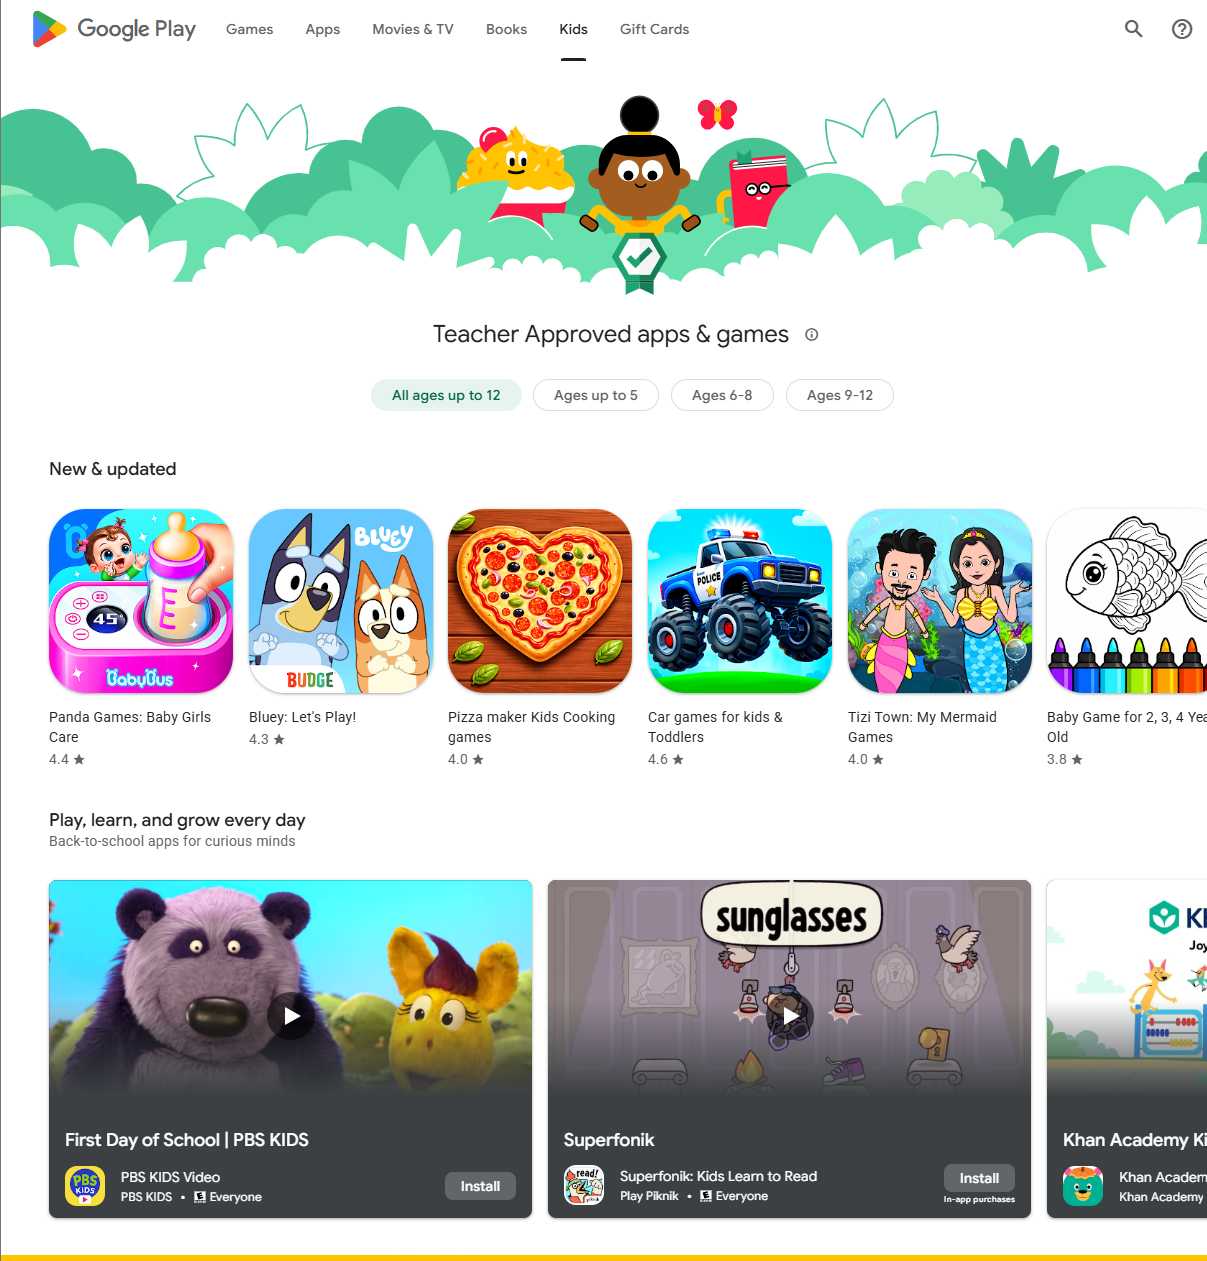

## Analysis: Most Popular Apps by Genre

### App Store Genres by Average Rating
Now that we know the general app landscape of each platform, we can dive into which genres actually have the most users. For the iOS data we will use the `rating_count_total` as a proxy for no direct comparison for installations in the dataset. The logic for the `rating_count_total` being the proxy is that the app which has a higher number of ratings has a higher number of users. Moreover, the highest average ratings also shows user engagement with the product, inherently displaying how likely they are to reccomend it to another user or not.

In [22]:
genres_ios = freq_table(ios_free, 12) #generates the genre list
for genre in genres_ios:
    total = 0
    len_genre = 0
    for app in ios_free:
        genre_app = app[12]
        if genre_app == genre:
            n_ratings = float(app[6])
            total += n_ratings
            len_genre += 1
    avg_n_ratings = total / len_genre
    print(genre, ';', avg_n_ratings)

Productivity ; 21028.410714285714
Weather ; 52279.892857142855
Shopping ; 26919.690476190477
Reference ; 74942.11111111111
Finance ; 31467.944444444445
Music ; 57326.530303030304
Utilities ; 18684.456790123455
Travel ; 28243.8
Social Networking ; 71548.34905660378
Sports ; 23008.898550724636
Health & Fitness ; 23298.015384615384
Games ; 22788.6696905016
Food & Drink ; 33333.92307692308
News ; 21248.023255813954
Book ; 39758.5
Photo & Video ; 28441.54375
Entertainment ; 14029.830708661417
Business ; 7491.117647058823
Lifestyle ; 16485.764705882353
Education ; 7003.983050847458
Navigation ; 86090.33333333333
Medical ; 612.0
Catalogs ; 4004.0


In the App Store, the average number of ratings for `Social Networking` is 71,548. The genre with the largest average number of ratings is `Navigation` with 86,090 ratings. Both of these are a bit misleading, with `Navigation` being heavily impacted buy the Waze and Google Maps apps. Moreover, `Social Networking` is misleading because it also displays reviews for very popular apps like Facebook, Skype, LinkedIn, and WhatsApp.

In [23]:
count = 0
for app in ios_free:
    if app[-5] == 'Social Networking':
        print(app[2], ':', app[6])
        count += 1
        if count == 20:
            break

Facebook : 2974676
LinkedIn : 71856
Skype for iPhone : 373519
Tumblr : 334293
Match™ - #1 Dating App. : 60659
WhatsApp Messenger : 287589
TextNow - Unlimited Text + Calls : 164963
Grindr - Gay and same sex guys chat, meet and date : 23201
imo video calls and chat : 18841
Ameba : 269
Weibo : 7265
Badoo - Meet New People, Chat, Socialize. : 34428
Kik : 260965
Qzone : 1649
Fake-A-Location Free ™ : 354
Tango - Free Video Call, Voice and Chat : 75412
MeetMe - Chat and Meet New People : 97072
SimSimi : 23530
Viber Messenger – Text & Call : 164249
Find My Family, Friends & iPhone - Life360 Locator : 43877


In [24]:
for app in ios_free:
    if app[-5] == 'Navigation':
        print(app[2], ':', app[6])
print('\n')

Waze - GPS Navigation, Maps & Real-time Traffic : 345046
Geocaching® : 12811
ImmobilienScout24: Real Estate Search in Germany : 187
Railway Route Search : 5
CoPilot GPS – Car Navigation & Offline Maps : 3582
Google Maps - Navigation & Transit : 154911




Notably, the `Games` genre fits into the middle of the pack, with an average of 22,788 reviewers, showing that popular games do not heavily influence or skew the results. This might mean that some sort of gaming app, even though it has a lot of competition could be lucrative in being successfull in the trial period.

Another key finding is how the `Health and Fitness` genre of apps is also in the middle of the pack, with 23,298 average reviews per app. Moreover, a look at which apps are on there, there seems to be a wide variety of running, calorie-tracking, workout, and other apps which don't overwhelmingly outcompete the market like the `Navigation` app. Instead the `Health and Fitness` genre has many apps with over 10,000 reviews.

In [25]:
count = 0
for app in ios_free:
    if app[-5] == 'Games':
        print(app[2], ':', app[6])
        count += 1
        if count == 20:
            break

Hangman. : 42316
Blackjack by MobilityWare : 180087
PAC-MAN : 508808
Beer Pong Game : 187315
NYTimes Crossword - Daily Word Puzzle Game : 53465
Sky Burger - Build & Match Food Free : 114096
Pixel Starships™ : 8Bit MMORPG : 5565
Angry Birds : 824451
Glow Hockey 2 FREE : 186653
Solitaire : 679055
Angry Birds HD : 89110
▻Sudoku : 359832
Virtual Regatta Offshore : 209
Jenga : 32527
Spider Solitaire Free by MobilityWare : 128739
Angry Birds Seasons HD : 75714
Fruit Ninja® : 327025
Temple Run : 1724546
Angry Birds Rio : 170843
Angry Birds Rio HD : 70122


In [26]:
count = 0
for app in ios_free:
    if app[-5] == 'Health & Fitness':
        print(app[2], ':', app[6])
        count += 1
        if count == 20:
            break

Lifesum – Inspiring healthy lifestyle app : 5795
Lose It! – Weight Loss Program and Calorie Counter : 373835
Nike+ Training Club - Workouts & Fitness Plans : 33969
Sleep Cycle alarm clock : 104539
Period Tracker Lite : 53620
Weight Watchers : 136833
My Cycles Period and Ovulation Tracker : 7469
Runtastic Running, Jogging and Walking Tracker : 10298
Calorie Counter & Diet Tracker by MyFitnessPal : 507706
Waterlogged - Daily Hydration Tracker : 5000
WebMD for iPad : 9142
Fooducate - Lose Weight, Eat Healthy,Get Motivated : 11875
My Score Plus Weight Loss, Food & Exercise Tracker : 467
VIBO RealMassager : 6
Fitbit : 90496
Headspace : 12819
Charity Miles: Walking & Running Distance Tracker : 3115
Sworkit - Custom Workouts for Exercise & Fitness : 16819
Fitstar Personal Trainer : 7496
Garmin Connect™ Mobile : 8341


### Google Play Categories by Average Installation
For the android store, we will use the `Installs` column for the analysis of which category of app has the most users. 

In Google Play, the largest average number of installations for `COMMUNICATION` apps is over 38 million. This makes sense because it is the basic intent for phones: communication. It contains video calling apps (like GoogleDuo), texting apps (Messenger), and emoji packs. Moreover, the second largest `Category` by average installations is `VIDEO_PLAYERS`, with over 24 million installations, but this is slightly misleadiong because of the over 1 billion installations by YouTube.

In [27]:
categories_android = freq_table(android_free, 1) #generates the cateogry list for android
for category in categories_android:
    total = 0
    len_category = 0
    for app in android_free:
        category_app = app[1]
        if category_app == category:
            n_installs = app[5]
            n_installs = n_installs.replace('+','')
            n_installs = n_installs.replace(',','')
            total += float(n_installs)
            len_category += 1
    avg_n_installs = total / len_category
    print(category, ';', avg_n_installs)

ART_AND_DESIGN ; 1986335.0877192982
AUTO_AND_VEHICLES ; 647317.8170731707
BEAUTY ; 513151.88679245283
BOOKS_AND_REFERENCE ; 8767811.894736841
BUSINESS ; 1712290.1474201474
COMICS ; 817657.2727272727
COMMUNICATION ; 38456119.167247385
DATING ; 854028.8303030303
EDUCATION ; 1833495.145631068
ENTERTAINMENT ; 11640705.88235294
EVENTS ; 253542.22222222222
FINANCE ; 1387692.475609756
FOOD_AND_DRINK ; 1924897.7363636363
HEALTH_AND_FITNESS ; 4188821.9853479853
HOUSE_AND_HOME ; 1331540.5616438356
LIBRARIES_AND_DEMO ; 638503.734939759
LIFESTYLE ; 1437816.2687861272
GAME ; 15588015.603248259
FAMILY ; 3697848.1731343283
MEDICAL ; 120550.61980830671
SOCIAL ; 23253652.127118643
SHOPPING ; 7036877.311557789
PHOTOGRAPHY ; 17840110.40229885
SPORTS ; 3638640.1428571427
TRAVEL_AND_LOCAL ; 13984077.710144928
TOOLS ; 10801391.298666667
PERSONALIZATION ; 5201482.6122448975
PRODUCTIVITY ; 16787331.344927534
PARENTING ; 542603.6206896552
WEATHER ; 5074486.197183099
VIDEO_PLAYERS ; 24727872.452830188
NEWS_AND_

In [28]:
count = 0
for app in android_free:
    if app[1] == 'COMMUNICATION':
        print(app[0], ':', app[5])
        count += 1
        if count == 20:
            break

WhatsApp Messenger : 1,000,000,000+
Messenger for SMS : 10,000,000+
My Tele2 : 5,000,000+
imo beta free calls and text : 100,000,000+
Contacts : 50,000,000+
Call Free – Free Call : 5,000,000+
Web Browser & Explorer : 5,000,000+
Browser 4G : 10,000,000+
MegaFon Dashboard : 10,000,000+
ZenUI Dialer & Contacts : 10,000,000+
Cricket Visual Voicemail : 10,000,000+
TracFone My Account : 1,000,000+
Xperia Link™ : 10,000,000+
TouchPal Keyboard - Fun Emoji & Android Keyboard : 10,000,000+
Skype Lite - Free Video Call & Chat : 5,000,000+
My magenta : 1,000,000+
Android Messages : 100,000,000+
Google Duo - High Quality Video Calls : 500,000,000+
Seznam.cz : 1,000,000+
Antillean Gold Telegram (original version) : 100,000+


In [29]:
count = 0
for app in android_free:
    if app[1] == 'VIDEO_PLAYERS':
        print(app[0], ':', app[5])
        count += 1
        if count == 20:
            break

YouTube : 1,000,000,000+
All Video Downloader 2018 : 1,000,000+
Video Downloader : 10,000,000+
HD Video Player : 1,000,000+
Iqiyi (for tablet) : 1,000,000+
Video Player All Format : 10,000,000+
Motorola Gallery : 100,000,000+
Free TV series : 100,000+
Video Player All Format for Android : 500,000+
VLC for Android : 100,000,000+
Code : 10,000,000+
Vote for : 50,000,000+
XX HD Video downloader-Free Video Downloader : 1,000,000+
OBJECTIVE : 1,000,000+
Music - Mp3 Player : 10,000,000+
HD Movie Video Player : 1,000,000+
YouCut - Video Editor & Video Maker, No Watermark : 5,000,000+
Video Editor,Crop Video,Movie Video,Music,Effects : 1,000,000+
YouTube Studio : 10,000,000+
video player for android : 10,000,000+


In contrast to the App Store ratings, the `GAME` category sits comfortablly within the top 5 highest average number of installations, with an average of 15.5 million. This makes sense because of the attractiveness of entertainment on phones, but there are a lot of games which have very small installations.

An interesting finding is with the `HEALTH_AND_FITNESS` category, which has an average installation of around 4.2 million installations per app. This means that the `HEALTH_AND_FITNESS` category lies around the middle of categories in terms of installations. Some of this is boosted by apps like Fitbit, but at the same time, a lot of installations are still above the 1 million mark. Maybe there could be a niche for a fitness app that is free but gamified based on the type of muscle group you want to work out? 

In [30]:
count = 0
for app in android_free:
    if app[1] == 'GAME':
        print(app[0], ':', app[5])
        count += 1
        if count == 20:
            break

Solitaire : 10,000,000+
Sonic Dash : 100,000,000+
PAC-MAN : 100,000,000+
Bubble Witch 3 Saga : 50,000,000+
Race the Traffic Moto : 10,000,000+
Marble - Temple Quest : 10,000,000+
Shooting King : 10,000,000+
Geometry Dash World : 10,000,000+
Jungle Marble Blast : 5,000,000+
Roll the Ball® - slide puzzle : 100,000,000+
Block Craft 3D: Building Simulator Games For Free : 50,000,000+
Farm Fruit Pop: Party Time : 1,000,000+
Love Balls : 50,000,000+
Piano Tiles 2™ : 100,000,000+
Pokémon GO : 100,000,000+
Paint Hit : 10,000,000+
Snake VS Block : 50,000,000+
Rolly Vortex : 10,000,000+
Woody Puzzle : 1,000,000+
Stack Jump : 10,000,000+


In [31]:
count = 0
for app in android_free:
    if app[1] == 'HEALTH_AND_FITNESS':
        print(app[0], ':', app[5])
        count += 1
        if count == 20:
            break

Step Counter - Calorie Counter : 500,000+
Lose Belly Fat in 30 Days - Flat Stomach : 5,000,000+
Pedometer - Step Counter Free & Calorie Burner : 1,000,000+
Six Pack in 30 Days - Abs Workout : 10,000,000+
Lose Weight in 30 Days : 10,000,000+
Pedometer : 10,000,000+
LG Health : 10,000,000+
Step Counter - Pedometer Free & Calorie Counter : 10,000,000+
Pedometer, Step Counter & Weight Loss Tracker App : 10,000,000+
Sportractive GPS Running Cycling Distance Tracker : 1,000,000+
30 Day Fitness Challenge - Workout at Home : 10,000,000+
Home Workout for Men - Bodybuilding : 1,000,000+
Fat Burning Workout - Home Weight lose : 100,000+
Buttocks and Abdomen : 500,000+
Walking for Weight Loss - Walk Tracker : 100,000+
Running & Jogging : 500,000+
Sleep Sounds : 1,000,000+
Fitbit : 10,000,000+
Lose Belly Fat-Home Abs Fitness Workout : 50,000+
Cycling - Bike Tracker : 500,000+


### Analysis: Diving Deeper

As we have seen in the initial filtering analysis of the genres and categories in the App Store and Google Play datasets, we have found a potential niche where we can dive into the Health and Fitness sphere of apps while providing gaming like features with the app. 

To investigate futher we want to see if there are any apps already dominating the market.

In [32]:
for app in android_free:
    if app[1] == 'HEALTH_AND_FITNESS' and (app[5] == '1,000,000,000+'
                                            or app[5] == '500,000,000+'
                                            or app[5] == '100,000,000+'):
        print(app[0], ':', app[5])

Period Tracker - Period Calendar Ovulation Tracker : 100,000,000+
Samsung Health : 500,000,000+


As we can see from the filtering in the Google Play dataset, we find there are only 2 apps with more than 100 million installations. This could be concerning, but when we take a deeper look into the applications, we can find that we can still find a niche in the health and fitness market. The app with 500+ million installations is the default `Samsung Health` app associated with Android that tracks things like steps per day. The other app with 100+ million installations is `Period Tracker`, a woman's menstrual cycle tracker, something that is already very specific. This niche is something that we can account for and not make the focus of the app.

Now that we know the market still has space for health and fitness which is not a general tracker or concerning the menstrual cycle, we can take a look at the mid-size market for health and fitness apps.

In [33]:
for app in android_free:
    if app[1] == 'HEALTH_AND_FITNESS' and (app[5] == '1,000,000+'
                                            or app[5] == '5,000,000+'
                                            or app[5] == '10,000,000+'
                                            or app[5] == '50,000,000+'):
        print(app[0], ':', app[5])

Lose Belly Fat in 30 Days - Flat Stomach : 5,000,000+
Pedometer - Step Counter Free & Calorie Burner : 1,000,000+
Six Pack in 30 Days - Abs Workout : 10,000,000+
Lose Weight in 30 Days : 10,000,000+
Pedometer : 10,000,000+
LG Health : 10,000,000+
Step Counter - Pedometer Free & Calorie Counter : 10,000,000+
Pedometer, Step Counter & Weight Loss Tracker App : 10,000,000+
Sportractive GPS Running Cycling Distance Tracker : 1,000,000+
30 Day Fitness Challenge - Workout at Home : 10,000,000+
Home Workout for Men - Bodybuilding : 1,000,000+
Sleep Sounds : 1,000,000+
Fitbit : 10,000,000+
Calorie Counter - EasyFit free : 1,000,000+
Garmin Connect™ : 10,000,000+
BetterMe: Weight Loss Workouts : 5,000,000+
Bike Computer - GPS Cycling Tracker : 1,000,000+
Running Distance Tracker + : 1,000,000+
Runkeeper - GPS Track Run Walk : 10,000,000+
Walking: Pedometer diet : 1,000,000+
8fit Workouts & Meal Planner : 10,000,000+
Keep Trainer - Workout Trainer & Fitness Coach : 1,000,000+
PumpUp — Fitness Co

As we can see from the mid-size market, there are a lot of different and successful avenues for mid-size health and fitness apps. Some of the general health and fitness themes include: calorie tracking, ab workouts, home workouts, running/walking tracker, and also surprisingly women's apps (health tips, menstrual, pregnancy) despite the 100+ million installations of the `Period Tracker`. With these overall themes in mind, we would want to steer clear of all of these.

However, in our investigation, we can see that there is a market for some daily yoga and yoga meditation sounds in the health app. There are only 5 apps related to yoga, showing a potential underserved market. Some of these apps surround giving the user yoga poses and sample yoga plans. Moreover, we see there are a lot of apps in the health market concerning tracking (like tracking calories or runs). We also see potential for people to connect over yoga on an app. There are successful apps, like `Strava`, connecting people to different running and walking communities, or even show progress to a friend.

These observations allow us to spot an opportunity for a daily yoga fitness tracker in the app market. Moreover to differentiate ourselves from conpeting apps we might want to develop additonal features. Some example features could be a level-up gaming componant; where the more consistent you are with the yoga tracker you get to discover newer poses beneficial to where their skill level is with yoga. For example, for a beginner it would level up and unlock beginner-fiendly poses. For advanced yoga practicers, they would unlock complicated positions or even challenges to complete. 

## Conclusions

In this project, we analyzed data from the App Store and Google Play to reccomend an app profile capable to be profitable in both markets.

After investigating the number of reviews and installation by app genre and category respectively, we were able to recommend an app profile that tracks yoga exercises and has some extra features. These extra features can help its appeal to a broader audience and overlap with other categories, like gaming. This is achieved through a level-up and challenge completion aspect to the yoga tracker.